# LEMUR Flyovers at REACH Site:

This notebook produces the experimental results used for identifying and visualising Spire Global's LEMUR satellite flyovers at the Radio Experiment for the Analysis of Cosmic Hydrogen (REACH) site in the Karoo radio reserve, South Africa. 

### Initialising Satellite Data:

Satellite Two-Line Elements (TLEs) are first loaded and filtered to identify the LEMUR satellites relevant within the observation window. Satellite trajectories are propagated using the specified observation durection and temporal resolution, while accounting for the REACH site coordinates and horizon profile.

In [15]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [16]:
# Time Array:
ts = load.timescale()
length = 3600*1.5 # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London",51.5,0.128], ["REACH",-30.7,-21.5]]

In [17]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=10,
    obs_lat=50,
    obs_lon=0.128,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="lemur"
)

Processing satellites:  31%|███       | 17/55 [00:02<00:04,  8.87satellite/s]c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:4620: RuntimeWarning: invalid value encountered in ld
  p1 = ufunc.ld(bm, p, q, e, em, dlim)
c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:19004: RuntimeWarning: invalid value encountered in anp
  c_retval = ufunc.anp(a)
Processing satellites: 100%|██████████| 55/55 [00:13<00:00,  4.02satellite/s]


In [23]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of Spire Global LEMUR Flyovers at REACH Site: {len(data)}")
print(f"List of NORADS: {', '.join(norads)}.")

Number of Spire Global LEMUR Flyovers at REACH Site: 6
List of NORADS: 42841, 42845, 58899, 58900, 58902, 58903.


### Plotting Time-Evolving Satellite Elevations from REACH:

Satellite elevations relative to the REACH site can be plotted as a function of time, where the plot below illustrates how the relative angular positions of individual flyovers evolves throughout the observation window. This is an especially important consideration for wide-beam radiometers, as instrument-related systematics are dominated by antenna chromaticity. Chromaticity arises because the antenna beam pattern is inherently frequency-dependent whereby the gain varies with frequency as well as sky position. Hence, satellite flyovers achieving $\phi \rightarrow 90^{\circ}$ are of particular interest as they pass close to zenith, although their relevance ultimately depends on their potential emission frequency.

C:\Users\lette\OneDrive\Desktop\Publications\RASTI AstroTrack Paper\astrotrack\astrotrack\satcon_properties.py:302: UserWarning: no explicit representation of timezones available for np.datetime64
  epochs_np = np.array([np.datetime64(e) for e in epochs])


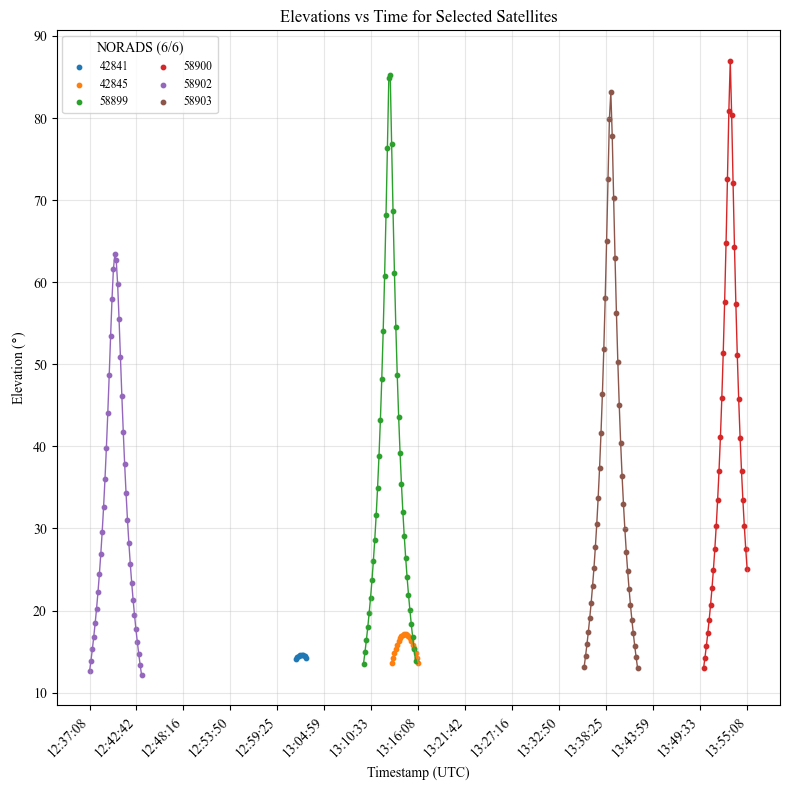

In [22]:
from astrotrack.satcon_properties import plot_satellite_metric


plot_satellite_metric(
    data,
    variable="Elevations",
    threshold=None,
    invert=False,
    font_family="Times New Roman",
    figsize=(8, 8)
)